In [64]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

In [65]:
DATA_PATH = Path("record18.labeled.json")
T = 0
FPS = 10

In [66]:
def load_frames(path):
    return json.loads(path.read_text())["frames"]

In [67]:
frames = load_frames(DATA_PATH)
print(len(frames), frames[0]["frame_number"], frames[-1]["frame_number"])

1231 1 1231


In [68]:
def get_frame(frames, t):
    return frames[t]

In [69]:
frame = get_frame(frames, T)
print(frame["frame_number"], len(frame["points"]))

1 9


In [70]:
def get_feature_values(frame, key):
    return [point[key] for point in frame["points"]]

In [71]:
print(frame["points"][0])

{'x': -0.002709, 'y': 0.072259, 'z': -0.048757, 'velocity': 0.0, 'snr': 237, 'noise': 601}


In [72]:
def get_feature_time_values(frames, key, fps):
    times = []
    values = []
    for index, frame in enumerate(frames):
        time = frame.get("time_s", index / fps)
        for point in frame["points"]:
            times.append(time)
            values.append(point[key])
    return times, values


In [73]:
def get_frame_times(frames, fps):
    return [frame.get("time_s", index / fps) for index, frame in enumerate(frames)]


In [74]:
def get_feature_means(frames, key):
    return [sum(point[key] for point in frame["points"]) / len(frame["points"]) for frame in frames]

In [75]:
def get_point_counts(frames):
    return [len(frame["points"]) for frame in frames]

In [76]:
def plot_feature_time(frames, fps, t):
    frame_times = get_frame_times(frames, fps)
    point_counts = get_point_counts(frames)
    selected_time = frame_times[t]
    feature_names = ["x", "y", "z", "velocity", "snr", "noise"]
    fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
    for axis, key in zip(axes.flat[:6], feature_names):
        times, values = get_feature_time_values(frames, key, fps)
        axis.scatter(times, values, s=8, alpha=0.35)
        axis.axvline(selected_time, color="red")
        axis.set_title(f"{key} over time")
        axis.set_ylabel(key)
    axes[3, 0].plot(frame_times, point_counts)
    axes[3, 0].axvline(selected_time, color="red")
    axes[3, 0].set_title("point count over time")
    axes[3, 0].set_ylabel("count")
    axes[3, 1].axis("off")
    axes[3, 0].set_xlabel("time (s)")
    axes[2, 0].set_xlabel("time (s)")
    axes[2, 1].set_xlabel("time (s)")
    fig.tight_layout()

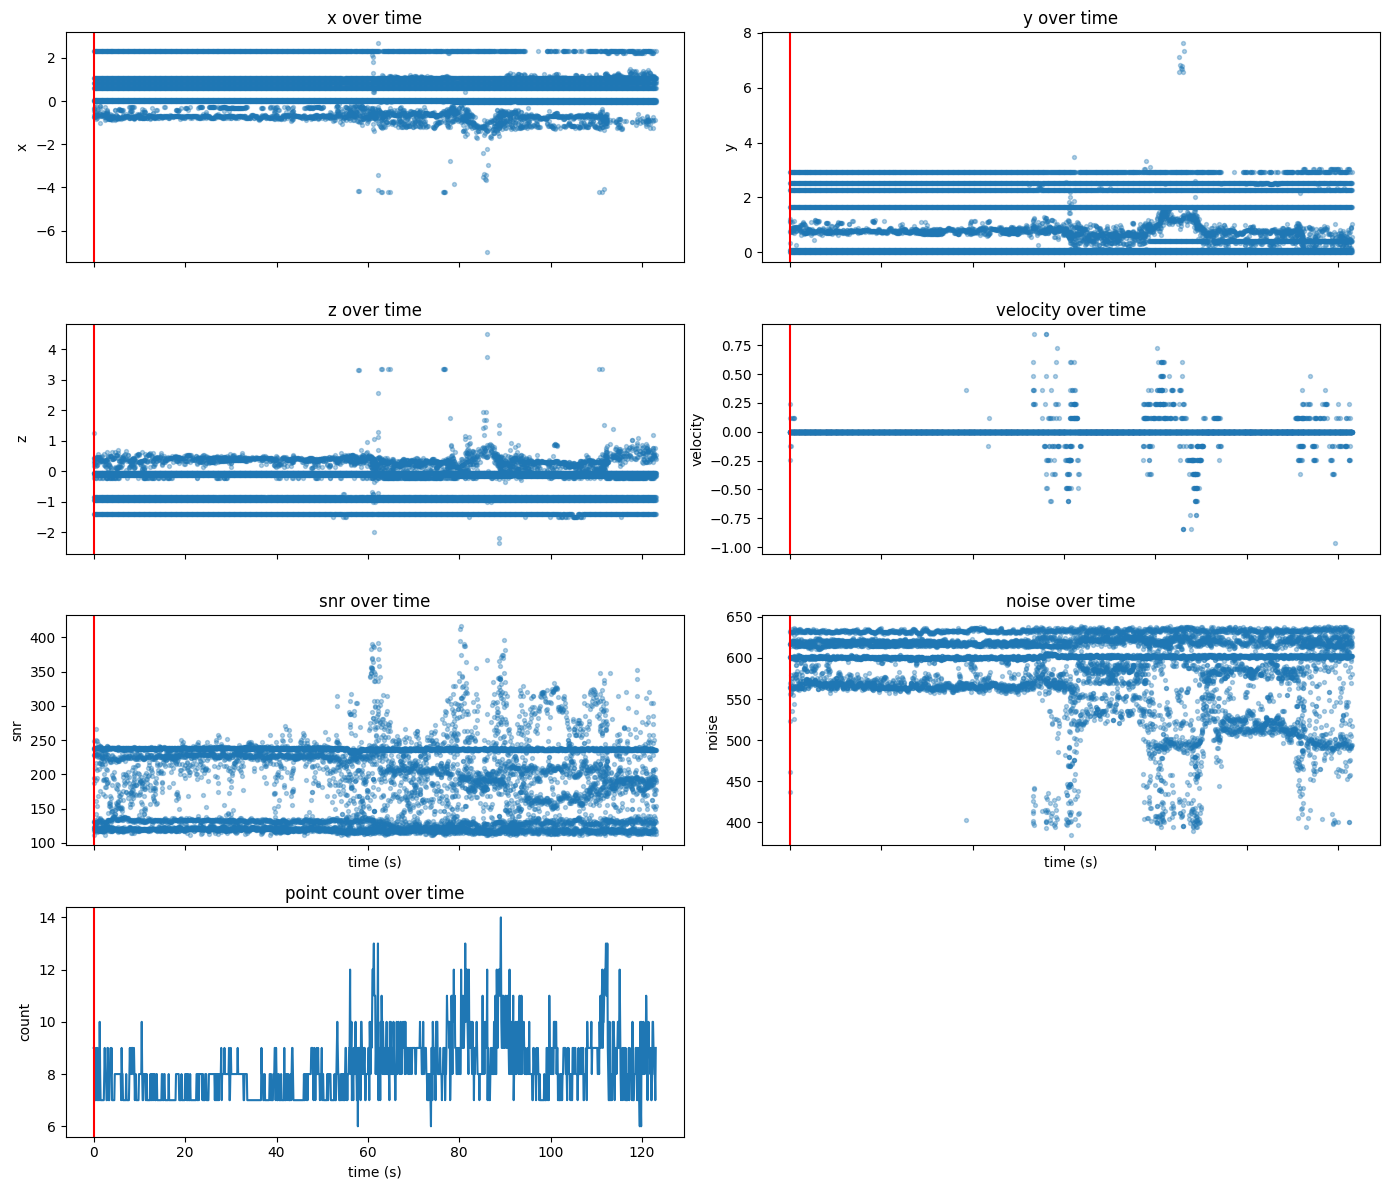

In [77]:
plot_feature_time(frames, FPS, T)

In [78]:
def plot_x_time(frames, fps, t):
    times, values = get_feature_time_values(frames, "x", fps)
    frame_times = get_frame_times(frames, fps)
    mean_values = get_feature_means(frames, "x")
    selected_time = frame_times[t]
    intervals = []
    start_time = None
    current_label = None
    for index, frame in enumerate(frames):
        label = frame.get("label", "unlabeled")
        time = frame.get("time_s", index / fps)
        if label == "unlabeled":
            if current_label is not None:
                intervals.append((start_time, time, current_label))
                current_label = None
                start_time = None
            continue
        if current_label is None:
            current_label = label
            start_time = time
        elif label != current_label:
            intervals.append((start_time, time, current_label))
            current_label = label
            start_time = time
    if current_label is not None:
        end_time = frames[-1].get("time_s", (len(frames) - 1) / fps) + 1 / fps
        intervals.append((start_time, end_time, current_label))
    label_names = sorted({label for _, _, label in intervals})
    palette = ["tab:orange", "tab:green", "tab:purple", "tab:brown", "tab:pink", "tab:olive", "tab:cyan", "tab:red"]
    label_colors = {label: palette[index % len(palette)] for index, label in enumerate(label_names)}
    fig, ax = plt.subplots(figsize=(16, 7))
    ax.scatter(times, values, s=10, alpha=0.25, color="tab:blue")
    ax.plot(frame_times, mean_values, color="black", linewidth=2)
    y_top = ax.get_ylim()[1]
    for start, end, label in intervals:
        color = label_colors[label]
        ax.axvspan(start, end, color=color, alpha=0.18)
        ax.text((start + end) / 2, y_top, label, ha="center", va="bottom", color=color)
    if label_names:
        handles = [plt.Line2D([0], [0], color=label_colors[label], linewidth=6, alpha=0.5) for label in label_names]
        ax.legend(handles, label_names, title="labels", loc="upper right")
    else:
        ax.text(0.01, 0.98, "no labeled intervals in loaded file", transform=ax.transAxes, ha="left", va="top")
    ax.axvline(selected_time, color="red")
    ax.set_title("x over time")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("x")
    fig.tight_layout()


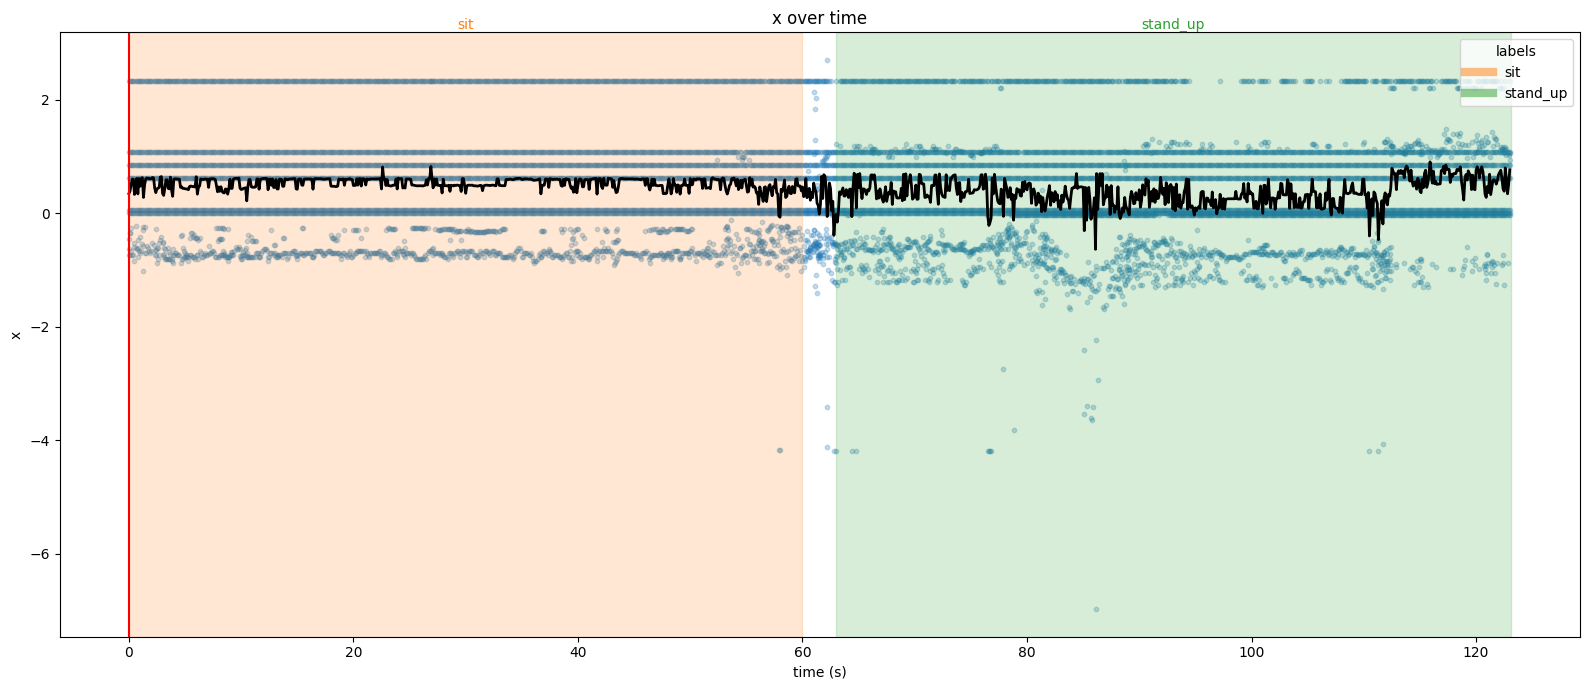

In [79]:
plot_x_time(frames, FPS, T)


In [80]:
def get_unique_labels(frames):
    return sorted({frame.get("label", "unlabeled") for frame in frames})


In [81]:
def get_label_counts(frames):
    counts = {}
    for frame in frames:
        label = frame.get("label", "unlabeled")
        counts[label] = counts.get(label, 0) + 1
    return counts


In [82]:
labels = get_unique_labels(frames)
print(labels[:5], len(labels))


['sit', 'stand_up', 'unlabeled'] 3


In [83]:
def get_labeled_frame_count(frames):
    return sum(1 for frame in frames if frame.get("label", "unlabeled") != "unlabeled")


In [84]:
label_counts = get_label_counts(frames)
print(get_labeled_frame_count(frames), label_counts.get("unlabeled", 0))

1201 30
